# DeBERTa Results Comparison

Compare metrics across DeBERTa runs (zero-shot, few-shot, LoRA) from timestamped folders in `results/`.

In [14]:
import json
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


In [59]:
# All data loading and configuration for DeBERTa reports lives here.
REPORTS_DIR = Path("reports")
FIGURES_DIR = REPORTS_DIR / "figures"
SAVE_FIGURES = True

MODEL_LABELS = {"zero_shot": "Zero-shot", "few_shot": "Few-shot", "lora": "LoRA"}

# Per-model subdirectories under reports/
MODEL_DIRS = {
    "zero_shot": REPORTS_DIR / "deberta_zero_shot",
    "few_shot": REPORTS_DIR / "deberta_few_shot",
    "lora": REPORTS_DIR / "deberta_lora",
}

# Filenames for test metrics and outputs inside each model directory
TEST_FILES = {
    "zero_shot": {
        "metrics": "deberta_zero_shot_test_metrics.json",
        "outputs": "deberta_zero_shot_test_outputs.json",
    },
    "few_shot": {
        "metrics": "deberta_few_shot_test_metrics.json",
        "outputs": "deberta_few_shot_test_outputs.json",
    },
    "lora": {
        "metrics": "deberta_lora_test_metrics.json",
        "outputs": "deberta_lora_test_outputs.json",
    },
}


def load_test_metrics(run_type: str) -> dict | None:
    base = MODEL_DIRS[run_type]
    path = base / TEST_FILES[run_type]["metrics"]
    return json.loads(path.read_text()) if path.exists() else None


def load_test_outputs(run_type: str) -> list | None:
    base = MODEL_DIRS[run_type]
    path = base / TEST_FILES[run_type]["outputs"]
    return json.loads(path.read_text()) if path.exists() else None


# Collect per-example test data for all models in a single pass
min_swaps_by_model: dict[str, list[float]] = {}
zero_one_acc_by_model: dict[str, list[float]] = {}

for run_type in MODEL_DIRS.keys():
    outputs = load_test_outputs(run_type)
    if outputs is None:
        continue

    min_swaps = [o["min_swaps"] for o in outputs if "min_swaps" in o]
    accuracies = [1.0 if o.get("correct", False) else 0.0 for o in outputs]

    if min_swaps:
        min_swaps_by_model[run_type] = min_swaps
    if accuracies:
        zero_one_acc_by_model[run_type] = accuracies

## Aggregate metrics comparison

Bar charts of zero-one accuracy, mean min swaps, and (when available) mean inference time by model and split.

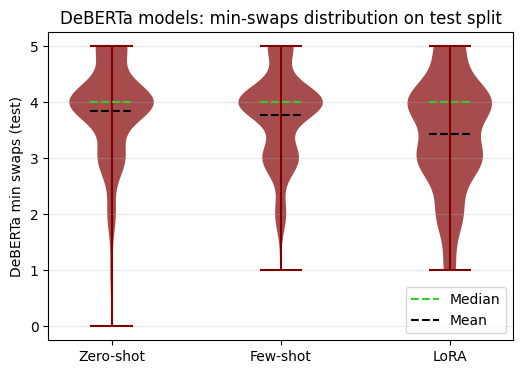

In [10]:
# DeBERTa min-swaps comparison on test split only
# We require all three DeBERTa variants to have data so the plot has 3 boxplots.
model_order = ["zero_shot", "few_shot", "lora"]

min_swaps_data = [min_swaps_by_model[m] for m in model_order]
labels = [MODEL_LABELS[m] for m in model_order]

plt.figure(figsize=(6, 4))
positions = np.arange(1, len(labels) + 1)

# Violin plot with built-in mean/median lines that span the violins
vp = plt.violinplot(
    min_swaps_data,
    positions=positions,
    showmeans=True,
    showmedians=True,
    showextrema=True,
)
vp['cmeans'].set_linestyle('--')
vp['cmeans'].set_color('black')
vp['cmeans'].set_linewidth(1.5)

vp['cmedians'].set_linestyle('--')
vp['cmedians'].set_color('limegreen')
vp['cmedians'].set_linewidth(1.5)

vp['cmins'].set_color('maroon')
vp['cmaxes'].set_color('maroon')

for body in vp['bodies']:
    body.set_facecolor('maroon')
    body.set_alpha(0.7) 
vp['cbars'].set_edgecolor('maroon')


plt.xticks(positions, labels)
plt.ylabel("DeBERTa min swaps (test)")
plt.title("DeBERTa models: min-swaps distribution on test split")
plt.grid(axis="y", alpha=0.3)

custom_lines = [
    Line2D([0], [0], color='limegreen', lw=1.5, linestyle='--'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--')
]
plt.legend(custom_lines, ['Median', 'Mean'], loc='best')

if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(
        FIGURES_DIR / "deberta_min_swaps_violin_test.png",
        bbox_inches="tight",
        dpi=200,
    )

plt.show()

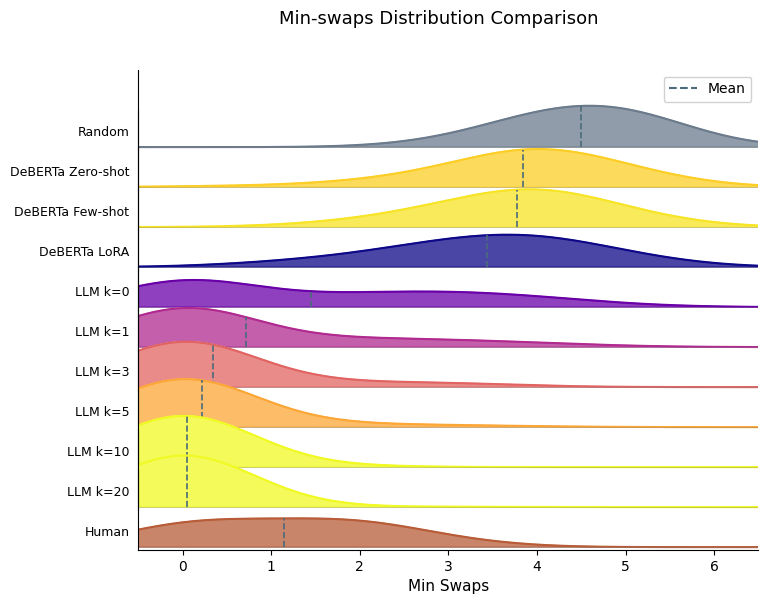

In [80]:
import csv
LLM_KS = [0, 1, 3, 5, 10, 20]
cmap = plt.cm.plasma
n_llm = len(LLM_KS)
n_deberta = 3
HUMAN_COLOR = "#b85c38"


def _load_min_swaps(path: Path) -> list:
    return [o["min_swaps"] for o in json.loads(path.read_text()) if "min_swaps" in o]


def _load_human_min_swaps() -> list:
    path = Path("data") / "human_measurement.csv"
    if not path.exists():
        return []
    with path.open(newline="") as f:
        return [int(row["Min Swaps"]) for row in csv.DictReader(f)]


def _load_random_min_swaps() -> list:
    path = REPORTS_DIR / "random_baseline" / "random_baseline_test_outputs.json"
    if not path.exists():
        return []
    data = json.loads(path.read_text())
    return [o["min_swaps"] for o in data if "min_swaps" in o]


def _gaussian_kde(data, x_vals, bw=0.8):
    d = np.asarray(data)[:, np.newaxis]
    kernels = np.exp(-0.5 * ((x_vals[np.newaxis, :] - d) / bw) ** 2) / (bw * np.sqrt(2 * np.pi))
    return kernels.mean(axis=0)


_human = _load_human_min_swaps()
_random = _load_random_min_swaps()
model_data_raw = (
    ([("Random", _random)] if _random else []) + 
    [
        ("DeBERTa Zero-shot", _load_min_swaps(REPORTS_DIR / "deberta_zero_shot" / "deberta_zero_shot_test_outputs.json")),
        ("DeBERTa Few-shot",  _load_min_swaps(REPORTS_DIR / "deberta_few_shot"  / "deberta_few_shot_test_outputs.json")),
        ("DeBERTa LoRA",      _load_min_swaps(REPORTS_DIR / "deberta_lora"      / "deberta_lora_test_outputs.json")),
    ]
    + [(f"LLM k={k}", _load_min_swaps(REPORTS_DIR / "LLM" / f"llm_k{k}_test_outputs.json")) for k in LLM_KS]
    + ([("Human", _human)] if _human else [])
)
RANDOM_COLOR = "#6b7b8c"
def _color_for(i, label):
    if label == "Human":
        return HUMAN_COLOR
    if label == "Random":
        return RANDOM_COLOR
    if i < 3:
        return cmap(0.85 + i * 0.05)
    return cmap((i - 3) / max(n_llm - 1, 1))
model_data = [(label, swaps, _color_for(i, label)) for i, (label, swaps) in enumerate(model_data_raw)]

n = len(model_data)
x_vals = np.linspace(-1, 12.5, 300)

kdes = [_gaussian_kde(swaps, x_vals) for _, swaps, _ in model_data]
max_density = max(y.max() for y in kdes)

fig, axes = plt.subplots(n, 1, figsize=(8, 6))
fig.subplots_adjust(hspace=-0.5, bottom=0.08)

for i, (label, swaps, color) in enumerate(model_data):
    ax = axes[i]
    y = kdes[i] / max_density
    mean_swap = np.mean(swaps)

    ax.set_zorder(i + 1)
    ax.set_facecolor("none")

    ax.fill_between(x_vals, 0, y, color="white")
    ax.fill_between(x_vals, 0, y, color=color, alpha=0.75)
    ax.plot(x_vals, y, color=color, linewidth=1.5)
    ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
    idx_mean = np.argmin(np.abs(x_vals - mean_swap))
    y_at_mean = y[idx_mean]
    ax.plot([mean_swap, mean_swap], [0, y_at_mean], color="#4a6b7a", linestyle="--", linewidth=1.2, clip_on=True)

    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(-0.05, 1.5)
    ax.set_yticks([])

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    if i < n - 1:
        ax.spines["bottom"].set_visible(False)
    ax.tick_params(bottom=False, labelbottom=False)

    ax.text(-0.6, 0.22, label, ha="right", va="center", fontsize=9, transform=ax.get_xaxis_transform())

axes[-1].set_zorder(n + 10)
axes[-1].set_xticks(np.arange(0, 7))
axes[-1].tick_params(bottom=True, labelbottom=True)
axes[-1].spines["bottom"].set_visible(True)
axes[-1].set_xlabel("Min Swaps", fontsize=11)
mean_line = Line2D([0], [0], color="#4a6b7a", linestyle="--", linewidth=1.5, label="Mean")
axes[0].legend(handles=[mean_line], loc="upper right", framealpha=0.9)
fig.suptitle("Min-swaps Distribution Comparison", fontsize=13, y=0.98)

if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(FIGURES_DIR / "ridge_plot_min_swaps.png", bbox_inches="tight", dpi=200)

plt.show()

## Before vs after December 30, 2023 (test only, LLM)

Compare min_swaps, zero-one accuracy, and inference time on test puzzles before vs on/after 2023-12-30, for all LLM versions.

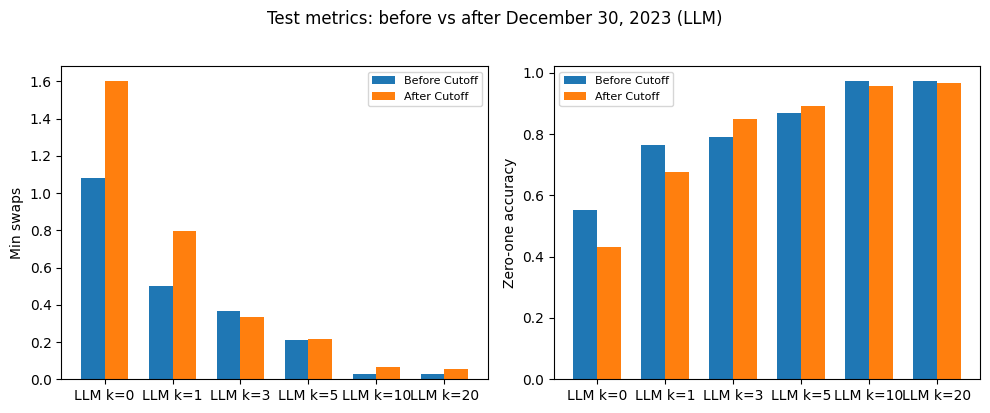

In [86]:
from datetime import datetime

CUTOFF = datetime(2023, 12, 30)
LLM_KS_BEFORE_AFTER = [0, 1, 3, 5, 10, 20]


def _parse_date(s: str):
    if not s:
        return None
    try:
        return datetime.strptime(s.strip()[:10], "%Y-%m-%d")
    except ValueError:
        return None


def _before_after_means_one(path: Path):
    if not path.exists():
        return None, None
    rows = json.loads(path.read_text())
    before = [r for r in rows if (_parse_date(r.get("date")) or CUTOFF) < CUTOFF]
    after = [r for r in rows if _parse_date(r.get("date")) and _parse_date(r.get("date")) >= CUTOFF]
    get = [lambda r: r.get("min_swaps", 0), lambda r: r.get("zero_one", 0.0)]
    b = [np.mean([g(r) for r in before]) if before else np.nan for g in get]
    a = [np.mean([g(r) for r in after]) if after else np.nan for g in get]
    return b, a


metric_labels = ["Min swaps", "Zero-one accuracy"]
before_by_llm = []
after_by_llm = []
for k in LLM_KS_BEFORE_AFTER:
    path = REPORTS_DIR / "LLM" / f"llm_k{k}_test_outputs.json"
    b, a = _before_after_means_one(path)
    before_by_llm.append(b if b else [np.nan, np.nan])
    after_by_llm.append(a if a else [np.nan, np.nan])

before_by_llm = np.array(before_by_llm)
after_by_llm = np.array(after_by_llm)
llm_labels = [f"LLM k={k}" for k in LLM_KS_BEFORE_AFTER]

if len(before_by_llm) and np.any(np.isfinite(before_by_llm)) or np.any(np.isfinite(after_by_llm)):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(llm_labels))
    w = 0.35
    for ax, mi, label in zip(axes, range(2), metric_labels):
        ax.bar(x - w / 2, before_by_llm[:, mi], w, color="C0", label="Before Cutoff")
        ax.bar(x + w / 2, after_by_llm[:, mi], w, color="C1", label="After Cutoff")
        ax.set_ylabel(label)
        ax.set_xticks(x)
        ax.set_xticklabels(llm_labels)
        ax.legend(loc="best", fontsize=8)
    fig.suptitle("Test metrics: before vs after December 30, 2023 (LLM)", fontsize=12, y=1.02)
    plt.tight_layout()
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / "before_after_2023-12-30_llm.png", bbox_inches="tight", dpi=200)
    plt.show()
else:
    print("No LLM test outputs found.")